# FC Barcelona Data Analysis
# Sources:
 1. FC Barcelona Official News
 2. BBC News


 In this analysis, data about FC Barcelona was collected from two different web sources: the official FC Barcelona website and BBC News.
The data was stored in MongoDB and later analyzed using pandas and matplotlib.
The analysis showed differences in the number of collected items per source and in the average title length.
In addition, common keywords in article titles highlighted the main themes appearing in the collected data.

תא 2 — ייבוא ספריות

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pymongo import MongoClient

תא 3 — חיבור למסד נתונים  

In [2]:
client = MongoClient("mongodb://localhost:27017/")
db = client["barcelona_db"]
collection = db["items"]

Cell 4 — Loading the data into a DataFrame

In [3]:
data = list(collection.find())
df = pd.DataFrame(data)

df.head()

,_id,team,source,title,text,date,author,url,collected_at,query,subreddit
0,69bfc362418c16f7a148c758,Barcelona,news,Barça 7-1 Palma: We are in the final Futsal cl...,,NaN,FC Barcelona Official Website,https://www.fcbarcelona.com/en/futsal/first-te...,2026-03-22 12:24:34,NaN,NaN
1,69bfc362418c16f7a148c759,Barcelona,news,label.aria.barcelonabadge Barça 7-1 Athletic C...,,NaN,FC Barcelona Official Website,https://www.fcbarcelona.com/en/football/womens...,2026-03-22 12:24:34,NaN,NaN
2,69bfc362418c16f7a148c75a,Barcelona,news,label.aria.barcelonabadge PREVIEW | Barça v Ra...,,NaN,FC Barcelona Official Website,https://www.fcbarcelona.com/en/football/first-...,2026-03-22 12:24:34,NaN,NaN
3,69bfc362418c16f7a148c75b,Barcelona,news,label.aria.barcelonabadge Calafell La Menorqui...,,NaN,FC Barcelona Official Website,https://www.fcbarcelona.com/en/roller-hockey/f...,2026-03-22 12:24:34,NaN,NaN
4,69bfc362418c16f7a148c75c,Barcelona,news,label.aria.barcelonabadge Ready for Barça v Ra...,,NaN,FC Barcelona Official Website,https://www.fcbarcelona.com/en/football/first-...,2026-03-22 12:24:34,NaN,NaN


Cell 5 — Basic cleaning

In [4]:
# הורדת _id אם מפריע
if "_id" in df.columns:
    df = df.drop(columns=["_id"])

df.head()

,team,source,title,text,date,author,url,collected_at,query,subreddit
0,Barcelona,news,Barça 7-1 Palma: We are in the final Futsal cl...,,NaN,FC Barcelona Official Website,https://www.fcbarcelona.com/en/futsal/first-te...,2026-03-22 12:24:34,NaN,NaN
1,Barcelona,news,label.aria.barcelonabadge Barça 7-1 Athletic C...,,NaN,FC Barcelona Official Website,https://www.fcbarcelona.com/en/football/womens...,2026-03-22 12:24:34,NaN,NaN
2,Barcelona,news,label.aria.barcelonabadge PREVIEW | Barça v Ra...,,NaN,FC Barcelona Official Website,https://www.fcbarcelona.com/en/football/first-...,2026-03-22 12:24:34,NaN,NaN
3,Barcelona,news,label.aria.barcelonabadge Calafell La Menorqui...,,NaN,FC Barcelona Official Website,https://www.fcbarcelona.com/en/roller-hockey/f...,2026-03-22 12:24:34,NaN,NaN
4,Barcelona,news,label.aria.barcelonabadge Ready for Barça v Ra...,,NaN,FC Barcelona Official Website,https://www.fcbarcelona.com/en/football/first-...,2026-03-22 12:24:34,NaN,NaN


Cell 6 — How many records are there?

In [5]:
print("Total records:", len(df))
print(df["source"].value_counts())

Total records: 52
source
reddit      21
bbc_news    19
news        12
Name: count, dtype: int64


תא 7 — גרף לפי מקור

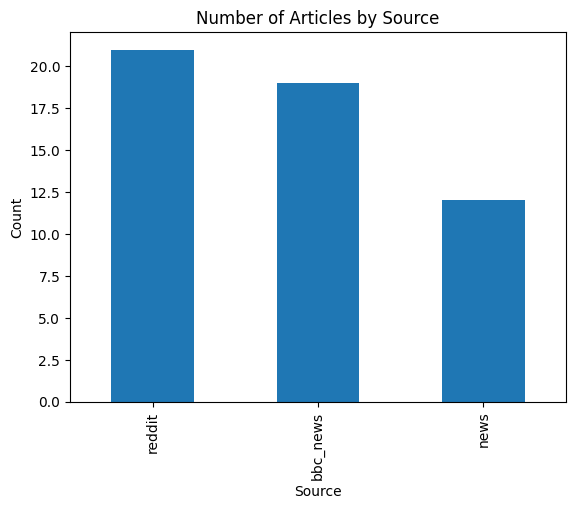

In [6]:
df["source"].value_counts().plot(kind="bar")
plt.title("Number of Articles by Source")
plt.xlabel("Source")
plt.ylabel("Count")
plt.show()

תא 8 — אורך כותרת

In [7]:
df["title_length"] = df["title"].astype(str).apply(len)

df.groupby("source")["title_length"].mean()

source
bbc_news     78.631579
news        201.166667
reddit       49.809524
Name: title_length, dtype: float64

תא 9 — גרף אורך כותרת ממוצע

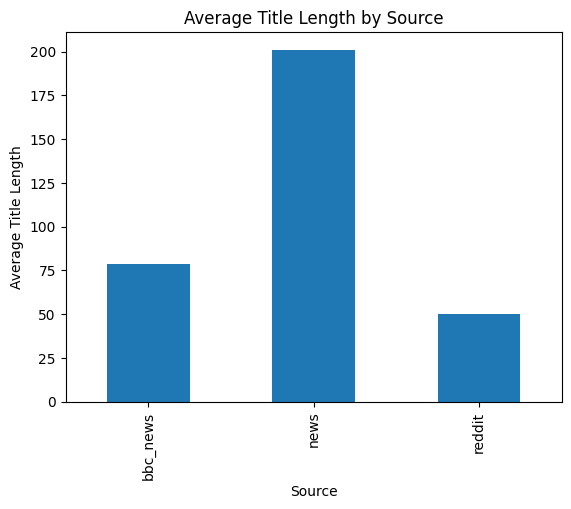

In [8]:
df.groupby("source")["title_length"].mean().plot(kind="bar")
plt.title("Average Title Length by Source")
plt.xlabel("Source")
plt.ylabel("Average Title Length")
plt.show()

תא 10 — החיפושים שבוצעו

In [9]:
if "query" in df.columns:
    print(df["query"].value_counts())

query
Barcelona    23
rayo         19
Name: count, dtype: int64


תא 11 — המילים הכי נפוצות בכותרות

In [10]:
from collections import Counter
import re

all_titles = " ".join(df["title"].astype(str).tolist()).lower()
words = re.findall(r"\b[a-zA-Z]+\b", all_titles)

stopwords = {
    "the", "and", "for", "with", "from", "this", "that", "into",
    "barcelona", "barca", "fc", "bbc", "news", "are", "was", "has"
}

filtered_words = [w for w in words if w not in stopwords and len(w) > 2]

word_counts = Counter(filtered_words)
word_counts.most_common(10)

[('rayo', 20),
 ('label', 19),
 ('aria', 19),
 ('vallecano', 18),
 ('clock', 11),
 ('newcastle', 11),
 ('barcelonabadge', 9),
 ('mar', 9),
 ('laliga', 7),
 ('team', 7)]

תא 12 — גרף 10 מילים נפוצות

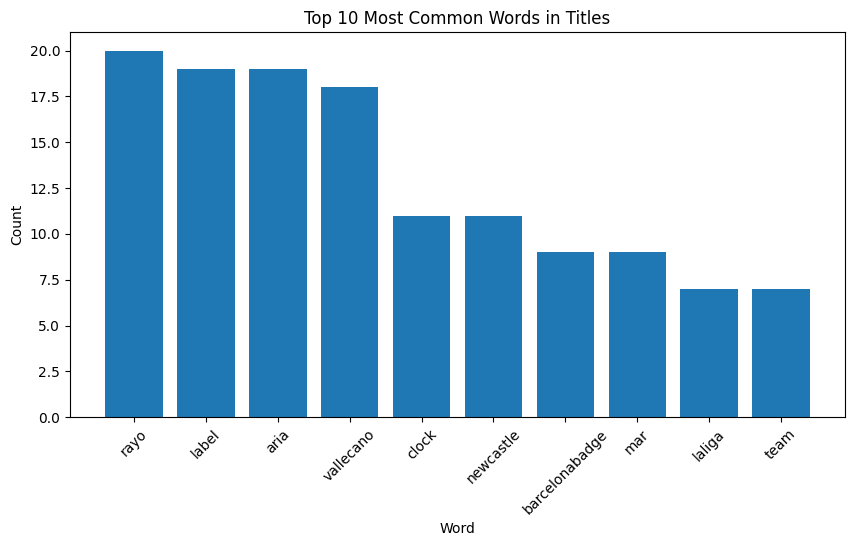

In [11]:
top_words = word_counts.most_common(10)

words = [w[0] for w in top_words]
counts = [w[1] for w in top_words]

plt.figure(figsize=(10, 5))
plt.bar(words, counts)
plt.title("Top 10 Most Common Words in Titles")
plt.xlabel("Word")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

תא 13 — טבלה מסכמת

In [12]:
df[["source", "query", "title", "url"]].head(15)

,source,query,title,url
0,news,NaN,Barça 7-1 Palma: We are in the final Futsal cl...,https://www.fcbarcelona.com/en/futsal/first-te...
1,news,NaN,label.aria.barcelonabadge Barça 7-1 Athletic C...,https://www.fcbarcelona.com/en/football/womens...
2,news,NaN,label.aria.barcelonabadge PREVIEW | Barça v Ra...,https://www.fcbarcelona.com/en/football/first-...
3,news,NaN,label.aria.barcelonabadge Calafell La Menorqui...,https://www.fcbarcelona.com/en/roller-hockey/f...
4,news,NaN,label.aria.barcelonabadge Ready for Barça v Ra...,https://www.fcbarcelona.com/en/football/first-...
5,news,NaN,label.aria.barcelonabadge Mobility and accessi...,https://www.fcbarcelona.com/en/news/4473258/mo...
6,news,NaN,label.aria.barcelonabadge Barça 7-1 Valdepeñas...,https://www.fcbarcelona.com/en/futsal/first-te...
7,news,NaN,label.aria.barcelonabadge The CAT Easter cake ...,https://www.fcbarcelona.com/en/club/news/44733...
8,news,NaN,label.aria.barcelonabadge When and where to wa...,https://www.fcbarcelona.com/en/football/first-...
9,news,NaN,label.aria.barcelonabadge Dani Olmo: 'We're mo...,https://www.fcbarcelona.com/en/football/first-...
